# DiffPO Confounding Diffusion Analysis

Compares DDIM denoising trajectories between DiffPO trained on clean IHDP (`naive_full`) and
DiffPO trained on confounded IHDP (`naive_conf`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from scipy.stats import gaussian_kde

from src.config import Config
from src.data import load_ihdp, make_ihdp_confounded
from src.model import DiffPO, _DiffusionBase

/home/justin/msc_ai/individual-project/diffusion-irregular-ehr/.claude/worktrees/diffpo-confounding-diffusion-analysis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CLEAN_CHECKPOINT = "checkpoints/final_model_naive_full_2026-08-03T16_14_47.pth"
CONF_CHECKPOINT = "checkpoints/final_model_naive_conf_2026-08-05T10_28_18.pth"
N_PER_GROUP = 10  # subjects per momblack group
SEED = 0
DEVICE = torch.device("cpu")

In [3]:
with open("config/ihdp.yaml") as f:
    cfg = Config.model_validate(yaml.safe_load(f))

# Pin to the diffusion schedule the available naive_full/naive_conf checkpoints were actually
# trained with. config/ihdp.yaml's diffusion.num_steps/beta_end were bumped (100->200, 0.2->0.1)
# in a later "update best diffusion params" commit that post-dates every checkpoint currently on
# disk, so loading state_dict against the current config's schedule shapes fails
# (beta_sched/alpha_sched/alpha_bar_sched: checkpoint shape (100,) vs. config-derived shape
# (200,)). Overriding here, rather than editing config/ihdp.yaml itself, keeps this notebook
# self-documenting about which schedule these specific checkpoints require.
cfg.diffusion.num_steps = 100
cfg.diffusion.beta_end = 0.2

clean_model = DiffPO(cfg.model, cfg.diffusion)
clean_model.load_state_dict(torch.load(CLEAN_CHECKPOINT, map_location=DEVICE))
clean_model.eval()

conf_model = DiffPO(cfg.model, cfg.diffusion)
conf_model.load_state_dict(torch.load(CONF_CHECKPOINT, map_location=DEVICE))
conf_model.eval()

print("clean_model.L:", clean_model.L, "  conf_model.L:", conf_model.L)

clean_model.L: 100   conf_model.L: 100


In [4]:
train_ds_clean, val_ds_clean, test_ds_clean, y_std = load_ihdp(
    cfg.data.path,
    replication=cfg.data.replication,
    train_ratio=cfg.data.train_ratio,
    test_ratio=cfg.data.test_ratio,
)
train_ds_conf, val_ds_conf, test_ds_conf = (
    make_ihdp_confounded(ds, effect=cfg.data.confounder_effect)
    for ds in (train_ds_clean, val_ds_clean, test_ds_clean)
)


def _clip_value(train_ds):
    if not cfg.diffusion.clip_denoised:
        return None
    y_both = _DiffusionBase._assemble_yboth(train_ds.a, train_ds.y, train_ds.y_cf)
    return 2 * y_both.abs().max().item()


clip_value_clean = _clip_value(train_ds_clean)
clip_value_conf = _clip_value(train_ds_conf)
print("clip_value_clean:", clip_value_clean, "  clip_value_conf:", clip_value_conf)

clip_value_clean: 6.018764972686768   clip_value_conf: 7.191953659057617


In [5]:
rng = np.random.default_rng(SEED)
confounder = test_ds_clean.confounder
assert confounder is not None

idx_flipped = np.flatnonzero(confounder == 1)
idx_control = np.flatnonzero(confounder == 0)
assert len(idx_flipped) >= N_PER_GROUP, f"only {len(idx_flipped)} momblack==1 test subjects"
assert len(idx_control) >= N_PER_GROUP, f"only {len(idx_control)} momblack==0 test subjects"

subset_idx = np.concatenate(
    [
        rng.choice(idx_flipped, size=N_PER_GROUP, replace=False),
        rng.choice(idx_control, size=N_PER_GROUP, replace=False),
    ]
)
momblack_t = torch.as_tensor(confounder[subset_idx])
flipped_mask = momblack_t == 1
control_mask = momblack_t == 0

x = test_ds_clean.x[subset_idx]
a_clean = test_ds_clean.a[subset_idx]
a_conf = test_ds_conf.a[subset_idx]

# mu0/mu1 differ by condition: cfg.data.confounder_effect=0.4 (config/ihdp.yaml) means
# make_ihdp_confounded doesn't just relabel treatment, it shifts the *true* potential
# outcomes for momblack==1 subjects (Hill's mechanism, applied in raw-outcome units then
# renormalised -- see src/data.py). Each model must be scored against its own condition's
# ground truth, matching how experiment.py's evaluate() does it -- never mu0_clean for the
# confound model or vice versa.
mu0_clean = test_ds_clean.mu0[subset_idx]
mu1_clean = test_ds_clean.mu1[subset_idx]
mu0_conf = test_ds_conf.mu0[subset_idx]
mu1_conf = test_ds_conf.mu1[subset_idx]

# Data-setup claim from the spec: momblack==0 subjects must see identical (x, a) in both
# conditions (built-in control group); momblack==1 subjects must see exactly-flipped a.
assert torch.equal(a_clean[control_mask], a_conf[control_mask])
assert torch.equal(a_conf[flipped_mask], 1.0 - a_clean[flipped_mask])
assert torch.equal(test_ds_clean.x[subset_idx], test_ds_conf.x[subset_idx])
# mu0/mu1 must also agree on the control group (only momblack==1 subjects' true POs shift).
# allclose, not equal: make_ihdp_confounded round-trips mu0/mu1 through denorm()/renorm() even
# for momblack==0 subjects (where the shift itself is a mathematical no-op), and that float32
# round trip is not bit-exact -- observed diffs are ~1e-7, i.e. float32 machine-epsilon noise,
# not a sign the mechanism touched control subjects.
assert torch.allclose(mu0_clean[control_mask], mu0_conf[control_mask], atol=1e-6)
assert torch.allclose(mu1_clean[control_mask], mu1_conf[control_mask], atol=1e-6)

print(
    f"Subset: {len(subset_idx)} subjects "
    f"({int(flipped_mask.sum())} momblack==1, {int(control_mask.sum())} momblack==0)"
)

Subset: 20 subjects (10 momblack==1, 10 momblack==0)


In [6]:
torch.manual_seed(SEED)
y_init = torch.randn(len(subset_idx), 2)

y_clean_final, y_clean_traj, eps_clean_traj = clean_model.sample_ddim(
    x, a_clean, y_init=y_init, clip_val=clip_value_clean, log_trajectory=True
)
y_conf_final, y_conf_traj, eps_conf_traj = conf_model.sample_ddim(
    x, a_conf, y_init=y_init, clip_val=clip_value_conf, log_trajectory=True
)

endpoint_dist = (y_clean_final - y_conf_final).norm(dim=1)
print("Mean endpoint distance (clean vs. confound):", endpoint_dist.mean().item())
print("Endpoint distance, momblack==1:", endpoint_dist[flipped_mask].mean().item())
print("Endpoint distance, momblack==0:", endpoint_dist[control_mask].mean().item())

Mean endpoint distance (clean vs. confound): 2.820326805114746
Endpoint distance, momblack==1: 2.6552109718322754
Endpoint distance, momblack==0: 2.985443115234375


In [7]:
K = cfg.train.K  # 50, per config/ihdp.yaml -- matches the codebase's normal eval convention

torch.manual_seed(SEED)
y0_clean, y1_clean = clean_model.sample_outcomes(x, a_clean, K=K, clip_val=clip_value_clean)
torch.manual_seed(SEED)
y0_conf, y1_conf = conf_model.sample_outcomes(x, a_conf, K=K, clip_val=clip_value_conf)

err_clean = (
    (y0_clean.mean(dim=1) - mu0_clean).abs() + (y1_clean.mean(dim=1) - mu1_clean).abs()
) / 2
err_conf = (
    (y0_conf.mean(dim=1) - mu0_conf).abs() + (y1_conf.mean(dim=1) - mu1_conf).abs()
) / 2

print("Mean |error| clean:", err_clean.mean().item())
print("Mean |error| confound:", err_conf.mean().item())
print("Mean |error| confound, momblack==1:", err_conf[flipped_mask].mean().item())
print("Mean |error| confound, momblack==0:", err_conf[control_mask].mean().item())

Mean |error| clean: 0.6164549589157104
Mean |error| confound: 0.7906100153923035
Mean |error| confound, momblack==1: 0.7717316746711731
Mean |error| confound, momblack==0: 0.8094884157180786


In [8]:
def cross_evaluate(other_model, y_traj, x_cond, a_cond):
    """other_model's eps_theta at every (y_traj[i], tau=L-1-i) pair, i.e. the same states
    the *anchor* trajectory visited, cross-evaluated on a different model's denoiser with
    the anchor's own (x_cond, a_cond) held fixed. y_traj: (L,B,2). Returns eps: (L,B,2)."""
    L, Bn, _ = y_traj.shape
    tau_grid = torch.arange(L - 1, -1, -1).unsqueeze(1).expand(L, Bn).reshape(-1)
    y_flat = y_traj.reshape(L * Bn, 2)
    x_flat = x_cond.unsqueeze(0).expand(L, Bn, -1).reshape(L * Bn, -1)
    a_flat = a_cond.unsqueeze(0).expand(L, Bn).reshape(-1)
    with torch.no_grad():
        eps_flat = other_model.denoiser(y_flat, tau_grid, x_flat, a_flat)
    return eps_flat.reshape(L, Bn, 2)


# d_tau: anchored on the clean trajectory, both terms use a_clean (spec: Two comparisons, B)
eps_conf_on_clean = cross_evaluate(conf_model, y_clean_traj, x, a_clean)
d_tau = eps_conf_on_clean - eps_clean_traj

# d_tau': anchored on the confound trajectory, both terms use a_conf
eps_clean_on_conf = cross_evaluate(clean_model, y_conf_traj, x, a_conf)
d_tau_prime = eps_conf_traj - eps_clean_on_conf

d_tau_norm = d_tau.norm(dim=-1)  # (L, N)
d_tau_prime_norm = d_tau_prime.norm(dim=-1)  # (L, N)

In [9]:
eps_clean_norm = eps_clean_traj.norm(dim=-1)  # (L, N)
ratio = (d_tau_norm.mean() / eps_clean_norm.mean()).item()
print(f"Mean ||d_tau|| = {d_tau_norm.mean().item():.4f}")
print(f"Mean ||eps_theta|| (clean) = {eps_clean_norm.mean().item():.4f}")
print(f"Ratio ||d_tau|| / ||eps_theta|| = {ratio:.4f}")

Mean ||d_tau|| = 0.2542
Mean ||eps_theta|| (clean) = 1.0831
Ratio ||d_tau|| / ||eps_theta|| = 0.2347


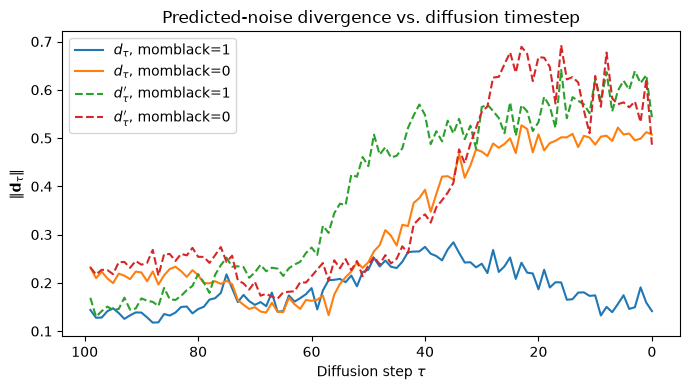

In [10]:
tau_axis = np.arange(cfg.diffusion.num_steps - 1, -1, -1)  # L-1 .. 0, matches trajectory order

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    tau_axis, d_tau_norm[:, flipped_mask].mean(dim=1).numpy(), label=r"$d_\tau$, momblack=1"
)
ax.plot(
    tau_axis, d_tau_norm[:, control_mask].mean(dim=1).numpy(), label=r"$d_\tau$, momblack=0"
)
ax.plot(
    tau_axis,
    d_tau_prime_norm[:, flipped_mask].mean(dim=1).numpy(),
    "--",
    label=r"$d_\tau'$, momblack=1",
)
ax.plot(
    tau_axis,
    d_tau_prime_norm[:, control_mask].mean(dim=1).numpy(),
    "--",
    label=r"$d_\tau'$, momblack=0",
)
ax.set_xlim(ax.get_xlim()[::-1])  # tau: L -> 0
ax.set_xlabel(r"Diffusion step $\tau$")
ax.set_ylabel(r"$\|\mathbf{d}_\tau\|$")
ax.set_title("Predicted-noise divergence vs. diffusion timestep")
ax.legend()
fig.tight_layout()
fig.savefig("images/confounding_divergence_vs_tau.png", dpi=150)
plt.show()

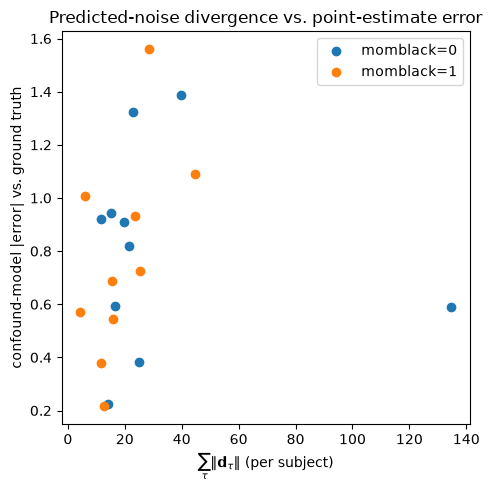

Pearson correlation, divergence vs. error: 0.0717


In [11]:
subject_divergence = d_tau_norm.sum(dim=0)  # (N,) -- sum_tau ||d_tau|| per subject

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    subject_divergence[control_mask].numpy(),
    err_conf[control_mask].numpy(),
    label="momblack=0",
)
ax.scatter(
    subject_divergence[flipped_mask].numpy(),
    err_conf[flipped_mask].numpy(),
    label="momblack=1",
)
ax.set_xlabel(r"$\sum_\tau \|\mathbf{d}_\tau\|$ (per subject)")
ax.set_ylabel("confound-model |error| vs. ground truth")
ax.set_title("Predicted-noise divergence vs. point-estimate error")
ax.legend()
fig.tight_layout()
fig.savefig("images/confounding_divergence_vs_error.png", dpi=150)
plt.show()

corr = np.corrcoef(subject_divergence.numpy(), err_conf.numpy())[0, 1]
print(f"Pearson correlation, divergence vs. error: {corr:.4f}")

In [12]:
L = cfg.diffusion.num_steps
SNAPSHOT_TAUS = [L - 1, 3 * L // 4, L // 2, L // 4, 0]  # L, 3L/4, L/2, L/4, 0 -- L-agnostic
DENSITY_K = 300
GRID_N = 40
GRID_RANGE = 4.0  # y0, y1 span, in normalised outcome units

subject_flipped = int(np.flatnonzero(flipped_mask.numpy())[0])
subject_control = int(np.flatnonzero(control_mask.numpy())[0])


def tau_to_traj_index(tau, L):
    """Trajectory index i logs tau = L-1-i (see _ddim_reverse/_ddpm_reverse docstrings)."""
    return (L - 1) - tau


def eps_grid(model, tau, x_subj, a_subj, grid_n=GRID_N, grid_range=GRID_RANGE):
    """model's eps_theta on a (grid_n, grid_n) grid of y=(y0,y1) at fixed tau, for one subject."""
    lin = torch.linspace(-grid_range, grid_range, grid_n)
    Y0, Y1 = torch.meshgrid(lin, lin, indexing="xy")
    y_grid = torch.stack([Y0.reshape(-1), Y1.reshape(-1)], dim=1)
    n = y_grid.shape[0]
    tau_t = torch.full((n,), tau, dtype=torch.long)
    x_rep = x_subj.unsqueeze(0).expand(n, -1)
    a_rep = a_subj.unsqueeze(0).expand(n)
    with torch.no_grad():
        eps = model.denoiser(y_grid, tau_t, x_rep, a_rep)
    return (
        Y0.numpy(),
        Y1.numpy(),
        eps[:, 0].reshape(grid_n, grid_n).numpy(),
        eps[:, 1].reshape(grid_n, grid_n).numpy(),
    )

In [13]:
def density_samples(model, tau, x_subj, a_subj, clip_val, K=DENSITY_K):
    """K independent stochastic reverse-trajectory samples of y_tau, for one subject."""
    x_rep = x_subj.unsqueeze(0).expand(K, -1)
    a_rep = a_subj.unsqueeze(0).expand(K)
    with torch.no_grad():
        _, y_traj, _ = model._ddpm_reverse(
            K, x_rep, a_rep, torch.device("cpu"), clip_val=clip_val, log_trajectory=True
        )
    return y_traj[tau_to_traj_index(tau, model.L)]  # (K, 2)


def kde_surface(samples, grid_n=GRID_N, grid_range=GRID_RANGE):
    kde = gaussian_kde(samples.numpy().T)
    lin = np.linspace(-grid_range, grid_range, grid_n)
    Y0, Y1 = np.meshgrid(lin, lin)
    Z = kde(np.vstack([Y0.ravel(), Y1.ravel()])).reshape(grid_n, grid_n)
    return Y0, Y1, Z


def plot_field_density(model, tau, x_subj, a_subj, clip_val, title, ax):
    """Item 1: KDE density surface + score quiver projected on the axes floor."""
    samples = density_samples(model, tau, x_subj, a_subj, clip_val)
    Y0d, Y1d, Z = kde_surface(samples)
    Y0f, Y1f, EPS0, EPS1 = eps_grid(model, tau, x_subj, a_subj)
    scale = (1.0 - model.alpha_bar_sched[tau]).clamp(min=1e-15).sqrt().item()
    score0, score1 = -EPS0 / scale, -EPS1 / scale  # the one place this notebook uses the score

    ax.plot_surface(Y0d, Y1d, Z, cmap="viridis", alpha=0.8)
    floor_z = Z.min() - 0.1 * (Z.max() - Z.min() + 1e-8)
    ax.quiver(
        Y0f,
        Y1f,
        np.full_like(Y0f, floor_z),
        score0,
        score1,
        np.zeros_like(score0),
        length=0.3,
        normalize=True,
        color="black",
    )
    ax.set_title(title)
    ax.set_xlabel(r"$y_0$")
    ax.set_ylabel(r"$y_1$")
    ax.set_zlabel(r"$\hat p_\tau(y)$")

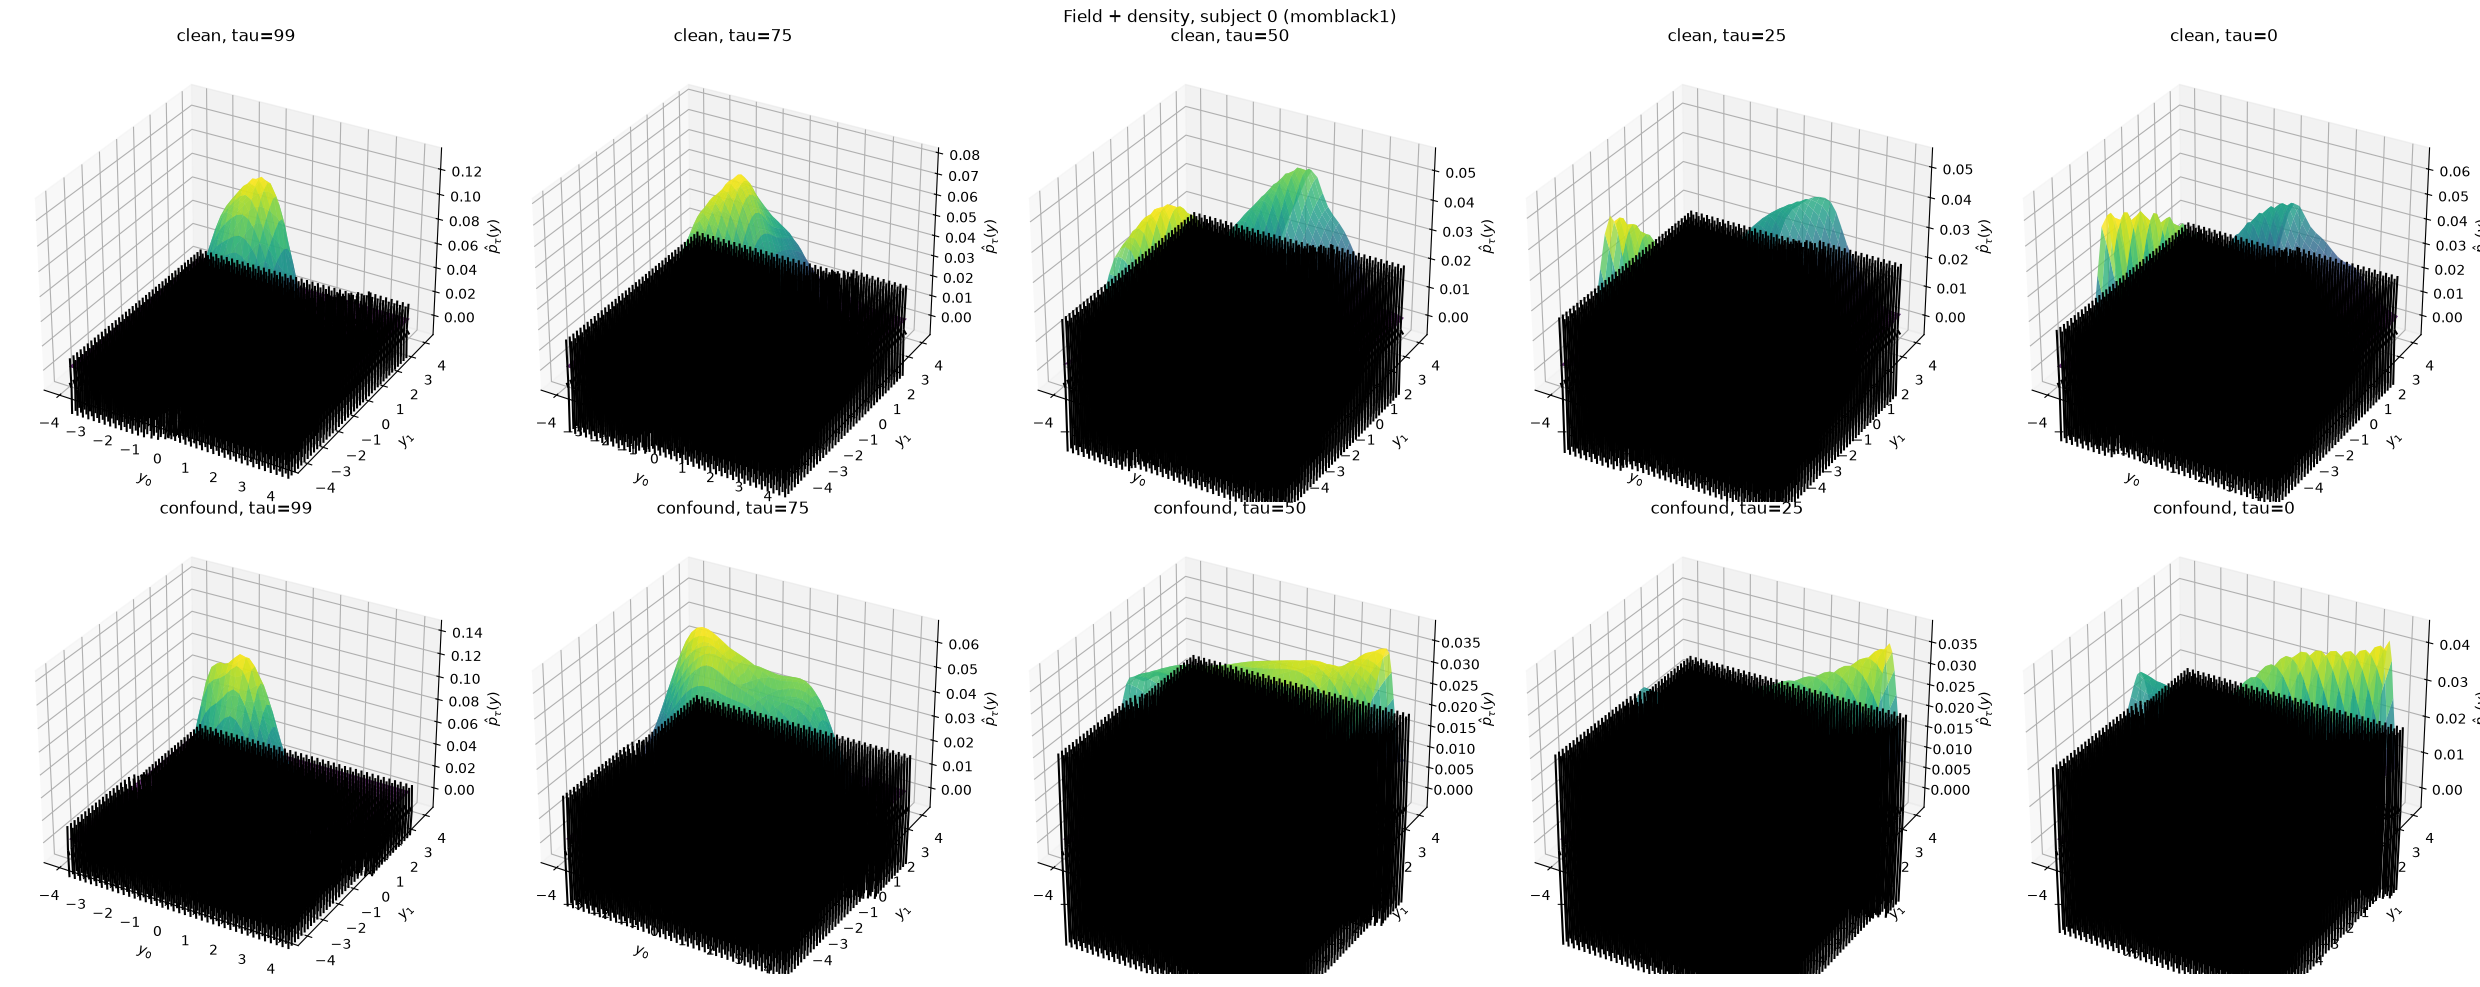

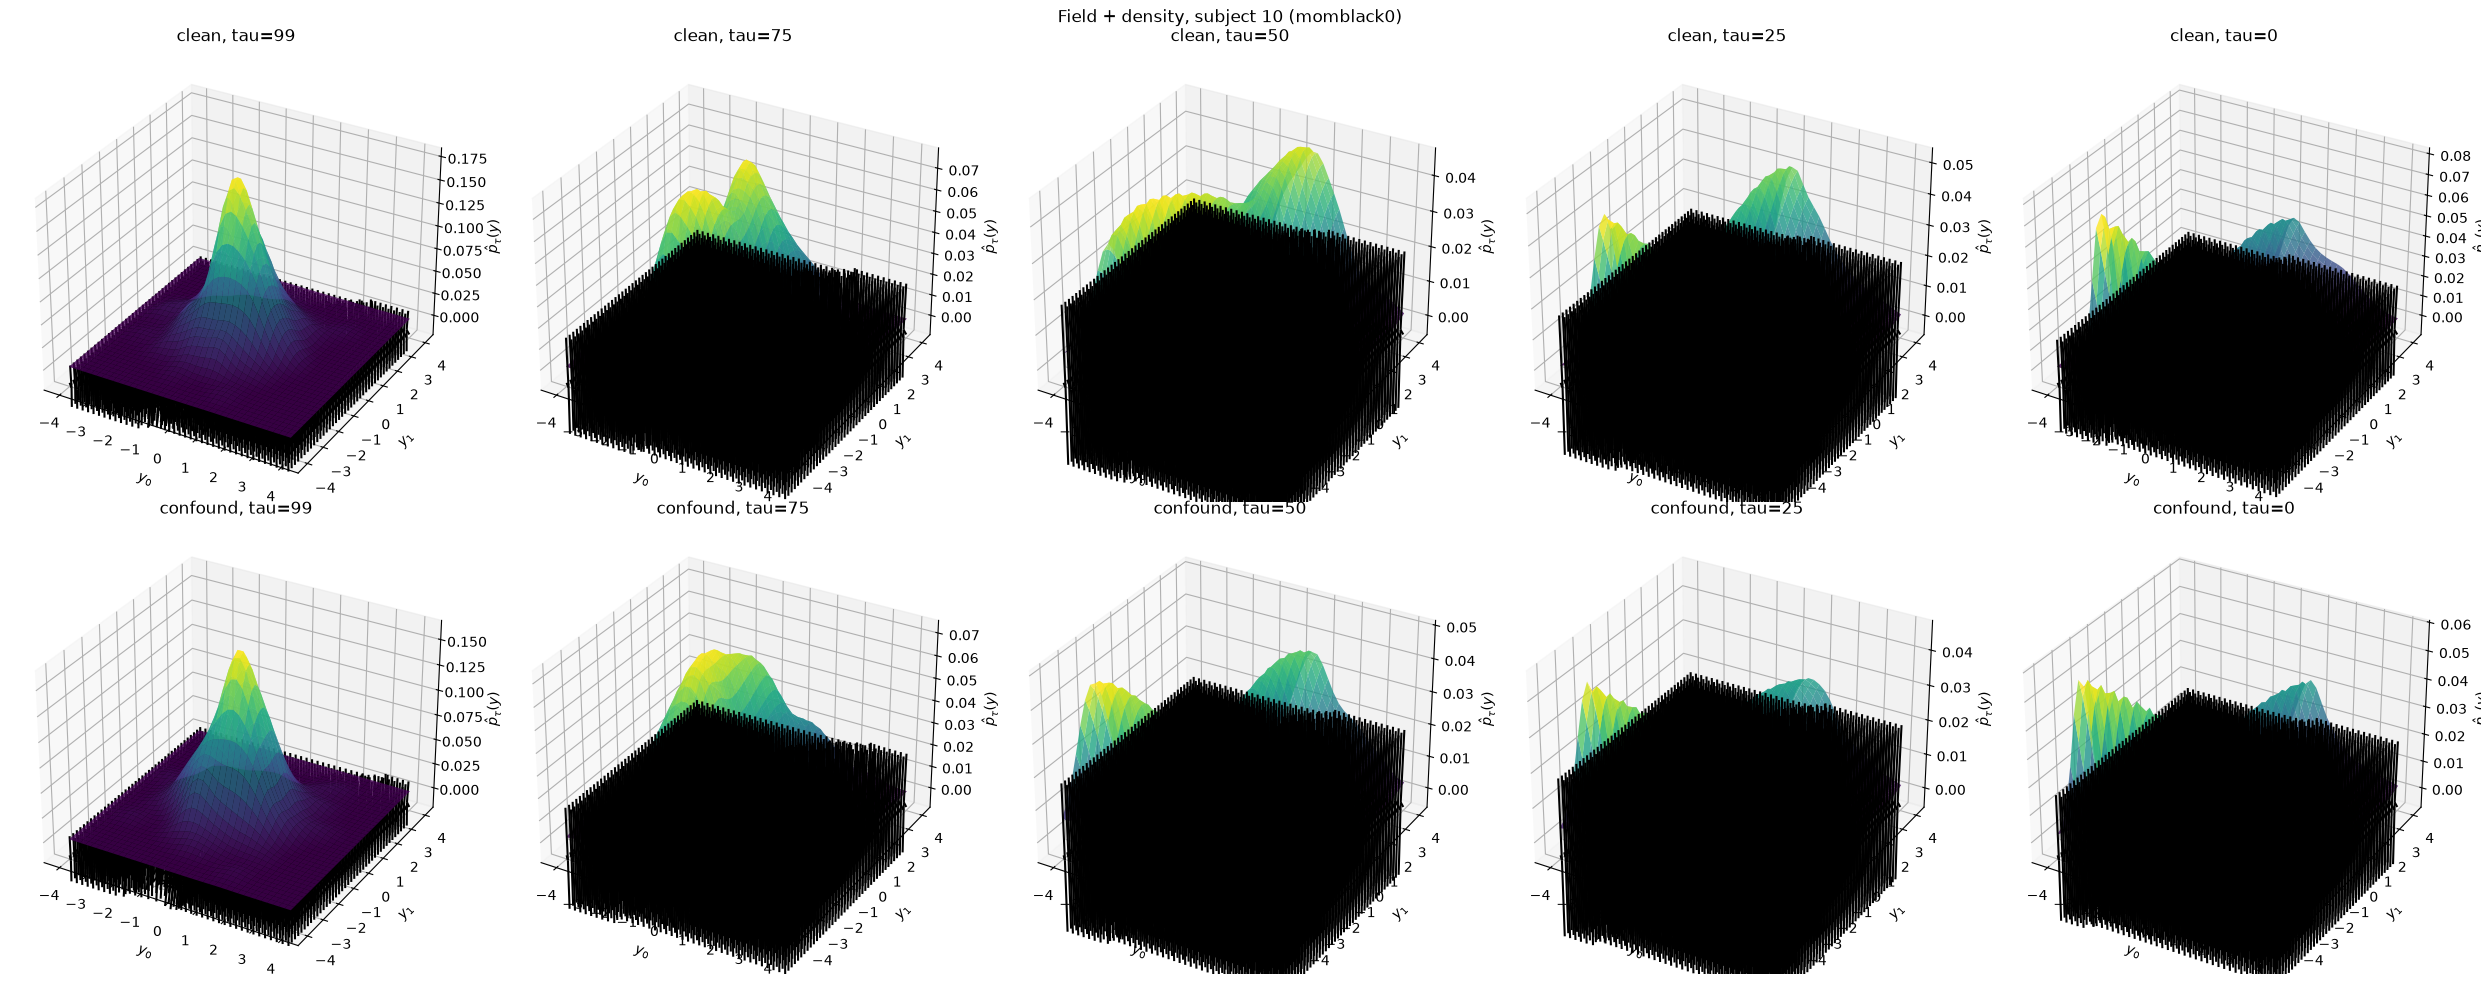

In [14]:
for subj_idx, subj_label in [(subject_flipped, "momblack1"), (subject_control, "momblack0")]:
    x_subj, a_clean_subj, a_conf_subj = x[subj_idx], a_clean[subj_idx], a_conf[subj_idx]

    fig = plt.figure(figsize=(5 * len(SNAPSHOT_TAUS), 10))
    for col, tau in enumerate(SNAPSHOT_TAUS):
        ax_clean = fig.add_subplot(2, len(SNAPSHOT_TAUS), col + 1, projection="3d")
        plot_field_density(
            clean_model,
            tau,
            x_subj,
            a_clean_subj,
            clip_value_clean,
            f"clean, tau={tau}",
            ax_clean,
        )
        ax_conf = fig.add_subplot(
            2, len(SNAPSHOT_TAUS), len(SNAPSHOT_TAUS) + col + 1, projection="3d"
        )
        plot_field_density(
            conf_model,
            tau,
            x_subj,
            a_conf_subj,
            clip_value_conf,
            f"confound, tau={tau}",
            ax_conf,
        )
    fig.suptitle(f"Field + density, subject {subj_idx} ({subj_label})")
    fig.tight_layout()
    fig.savefig(f"images/confounding_field_density_{subj_label}.png", dpi=150)
    plt.show()